# Spatial Inequalities in Emergency Medical Services Response Times in New York City

**A Machine-Learning–Based Analysis**

---

## Project Overview

This notebook analyzes spatial inequalities in EMS response times across NYC neighborhoods (2019-2024), combining:
- NYC Open Data: EMS Incident Dispatch Data
- US Census: American Community Survey (ACS) socioeconomic indicators

**Research Questions:**
1. How are EMS response times distributed across NYC neighborhoods?
2. Are response times associated with neighborhood socioeconomic characteristics?
3. Can machine learning reveal residual disparities in service delivery?

---

**Team Members:**
- Qianchenyu (Data Collection, Spatial Analysis)
- Jia & Yuanseng (Machine Learning Engineering)

---

# Part 0: Setup

## 0.1 Import All Libraries

In [1]:
# Standard libraries
import os
import warnings
from datetime import datetime, timedelta

# Data manipulation
import numpy as np
import pandas as pd

# API requests
import requests

# Spatial analysis
import geopandas as gpd
import matplotlib.pyplot as plt

# Census data
try:
    import cenpy
except ImportError:
    print("Installing cenpy...")
    !pip install cenpy python-Levenshtein -q
    import cenpy

# Spatial statistics (install if needed)
try:
    from pysal.lib import weights
    from pysal.explore import esda
    import splot
    from splot.esda import lisa_cluster, moran_scatterplot
except ImportError:
    print("Installing PySAL packages...")
    !pip install pysal esda splot libpysal -q
    from pysal.lib import weights
    from pysal.explore import esda
    import splot
    from splot.esda import lisa_cluster, moran_scatterplot

# Suppress warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 100)

print("✓ All libraries imported successfully")
print(f"  - pandas: {pd.__version__}")
print(f"  - geopandas: {gpd.__version__}")
print(f"  - cenpy: {cenpy.__version__}")

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


✓ All libraries imported successfully
  - pandas: 2.3.3
  - geopandas: 1.1.1
  - cenpy: 1.0.1


/Users/alex._choo/anaconda3/envs/spatial/lib/python3.10/site-packages/spaghetti/network.py:41: FutureWarning: The next major release of pysal/spaghetti (2.0.0) will drop support for all ``libpysal.cg`` geometries. This change is a first step in refactoring ``spaghetti`` that is expected to result in dramatically reduced runtimes for network instantiation and operations. Users currently requiring network and point pattern input as ``libpysal.cg`` geometries should prepare for this simply by converting to ``shapely`` geometries.
  warnings.warn(dep_msg, FutureWarning, stacklevel=1)


## 0.2 Configuration

In [2]:
# Path configuration
desktop_path = os.path.join(os.path.expanduser("~"), "Desktop")

# File paths
GEOJSON_PATH = os.path.join(desktop_path, "nyc_ems_spatial.geojson")
CSV_PATH = os.path.join(desktop_path, "nyc_ems_data_2019_2024.csv")

print("File paths configured:")
print(f"  CSV: {CSV_PATH}")
print(f"  GeoJSON: {GEOJSON_PATH}")

File paths configured:
  CSV: /Users/alex._choo/Desktop/nyc_ems_data_2019_2024.csv
  GeoJSON: /Users/alex._choo/Desktop/nyc_ems_spatial.geojson


# Part 1: Load or Collect EMS Data

## 1.1 Try Loading Previously Saved Data

**Fast path:** If you've already run the data collection, this will load your saved files.

**Note:** If files don't exist, jump to **Section 1.2** to collect data from scratch.

In [3]:
print("="*80)
print("LOADING PREVIOUSLY SAVED EMS DATA")
print("="*80)

data_loaded = False

# Try loading GeoJSON (contains both EMS data and spatial boundaries)
if os.path.exists(GEOJSON_PATH):
    try:
        gdf_final = gpd.read_file(GEOJSON_PATH)
        print(f"✓ Loaded spatial dataset: {len(gdf_final)} ZIP codes")
        print(f"  Columns: {len(gdf_final.columns)}")
        print(f"  CRS: {gdf_final.crs}")
        data_loaded = True
        
        # Also load CSV for reference
        if os.path.exists(CSV_PATH):
            df_agg = pd.read_csv(CSV_PATH)
            print(f"✓ Loaded CSV data: {len(df_agg)} ZIP codes")
        
    except Exception as e:
        print(f"✗ Error loading GeoJSON: {e}")
        data_loaded = False
else:
    print(f"✗ GeoJSON not found at: {GEOJSON_PATH}")

if data_loaded:
    print("\n" + "="*80)
    print("✓ DATA LOADED SUCCESSFULLY - Skip to Part 2 (ACS Data)")
    print("="*80)
    print("\nPreview:")
    print(gdf_final[['ZIPCODE', 'BOROUGH', 'INCIDENT_COUNT', 'AVG_RESPONSE_MIN']].head())
else:
    print("\n" + "="*80)
    print("⚠ NO SAVED DATA FOUND")
    print("="*80)
    print("Please run Section 1.2 below to collect EMS data from NYC Open Data API")
    print("(This is a ONE-TIME process that takes 15-20 minutes)")

LOADING PREVIOUSLY SAVED EMS DATA
✓ Loaded spatial dataset: 209 ZIP codes
  Columns: 14
  CRS: EPSG:4269
✓ Loaded CSV data: 237 ZIP codes

✓ DATA LOADED SUCCESSFULLY - Skip to Part 2 (ACS Data)

Preview:
  ZIPCODE    BOROUGH  INCIDENT_COUNT  AVG_RESPONSE_MIN
0   10152  MANHATTAN              39         11.161966
1   10153  MANHATTAN             325         11.064667
2   10168  MANHATTAN             720          7.886620
3   11229   BROOKLYN           46756          9.083133
4   11363     QUEENS            2610         10.442605


---

## 1.2 [OPTIONAL] Collect EMS Data from NYC Open Data API

**⚠️ ONLY RUN THIS SECTION IF YOU DON'T HAVE SAVED DATA (see output above)**

This section fetches 2019-2024 EMS data from NYC Open Data and creates spatial dataset.

**Time required:** 15-20 minutes

### 1.2.1 Configure API Parameters

In [4]:
# NYC Open Data API endpoint
API_ENDPOINT = "https://data.cityofnewyork.us/resource/76xm-jjuj.json"

# Optional: add your API token for higher rate limits
APP_TOKEN = None  

headers = {}
if APP_TOKEN:
    headers['X-App-Token'] = APP_TOKEN

# Select relevant fields
select_fields = [
    'zipcode',
    'borough',
    'incident_datetime',
    'incident_response_seconds_qy',
    'initial_severity_level_code',
    'initial_call_type',
    'incident_disposition_code',
    'cad_incident_id',
    'valid_incident_rspns_time_indc'
]

print("API configured")
print(f"Endpoint: {API_ENDPOINT}")
print(f"Fields to retrieve: {len(select_fields)}")

API configured
Endpoint: https://data.cityofnewyork.us/resource/76xm-jjuj.json
Fields to retrieve: 9


### 1.2.2 Fetch EMS Data (2019-2024)

In [5]:
def fetch_ems_data_by_year(year, select_fields, api_endpoint, headers):
    """
    Fetch EMS data for a single year with pagination
    """
    params = {
        '$select': ','.join(select_fields),
        '$where': f"incident_datetime >= '{year}-01-01T00:00:00' AND incident_datetime < '{year+1}-01-01T00:00:00'",
        '$limit': 50000,
        '$offset': 0,
        '$order': 'incident_datetime DESC'
    }
    
    all_data = []
    page_num = 0
    
    print(f"\n--- Fetching {year} data ---")
    
    while True:
        params['$offset'] = page_num * params['$limit']
        
        try:
            response = requests.get(api_endpoint, params=params, headers=headers, timeout=60)
            response.raise_for_status()
            data = response.json()
            
            if not data:
                print(f"  Completed {year}: Total {len(all_data):,} records")
                break
                
            all_data.extend(data)
            print(f"  Page {page_num + 1}: +{len(data):,} records (cumulative: {len(all_data):,})")
            
            if len(data) < params['$limit']:
                print(f"  Completed {year}: Total {len(all_data):,} records")
                break
                
            page_num += 1
            
        except requests.exceptions.RequestException as e:
            print(f"  Error fetching {year} data: {e}")
            break
    
    return pd.DataFrame(all_data)

# Fetch data for years 2019-2024
years = range(2019, 2025)
df_list = []

print("="*80)
print("FETCHING EMS DATA: 2019-2024")
print("="*80)

for year in years:
    df_year = fetch_ems_data_by_year(year, select_fields, API_ENDPOINT, headers)
    df_list.append(df_year)
    print(f"  ✓ {year}: {len(df_year):,} records collected")

# Combine all years
df = pd.concat(df_list, ignore_index=True)

print("\n" + "="*80)
print("DATA COLLECTION COMPLETE")
print("="*80)
print(f"Total records: {len(df):,}")
print(f"Time period: 2019-2024")

FETCHING EMS DATA: 2019-2024

--- Fetching 2019 data ---
  Page 1: +50,000 records (cumulative: 50,000)
  Page 2: +50,000 records (cumulative: 100,000)
  Page 3: +50,000 records (cumulative: 150,000)
  Page 4: +50,000 records (cumulative: 200,000)
  Page 5: +50,000 records (cumulative: 250,000)
  Page 6: +50,000 records (cumulative: 300,000)
  Page 7: +50,000 records (cumulative: 350,000)
  Page 8: +50,000 records (cumulative: 400,000)
  Page 9: +50,000 records (cumulative: 450,000)
  Page 10: +50,000 records (cumulative: 500,000)
  Page 11: +50,000 records (cumulative: 550,000)
  Page 12: +50,000 records (cumulative: 600,000)
  Page 13: +50,000 records (cumulative: 650,000)
  Page 14: +50,000 records (cumulative: 700,000)
  Page 15: +50,000 records (cumulative: 750,000)
  Page 16: +50,000 records (cumulative: 800,000)
  Page 17: +50,000 records (cumulative: 850,000)
  Page 18: +50,000 records (cumulative: 900,000)
  Page 19: +50,000 records (cumulative: 950,000)
  Page 20: +50,000 rec

### 1.2.3 Clean and Aggregate Data

In [6]:
print("="*80)
print("DATA CLEANING")
print("="*80)

# Convert response time to numeric
df['incident_response_seconds_qy'] = pd.to_numeric(
    df['incident_response_seconds_qy'], 
    errors='coerce'
)

print(f"Original dataset: {len(df):,} records")

# Apply quality filters
df_clean = df[
    (df['zipcode'].notna()) &
    (df['incident_response_seconds_qy'].notna()) &
    (df['incident_response_seconds_qy'] > 0) &
    (df['incident_response_seconds_qy'] < 3600) &
    (df['valid_incident_rspns_time_indc'] == 'Y')
].copy()

print(f"After quality filtering: {len(df_clean):,} records")
print(f"Records removed: {len(df) - len(df_clean):,} ({100*(len(df)-len(df_clean))/len(df):.1f}%)")

# Aggregate by ZIP code
df_agg = df_clean.groupby('zipcode').agg({
    'cad_incident_id': 'count',
    'incident_response_seconds_qy': 'mean',
    'borough': 'first'
}).reset_index()

df_agg.columns = ['ZIPCODE', 'INCIDENT_COUNT', 'AVG_RESPONSE_SEC', 'BOROUGH']
df_agg['AVG_RESPONSE_MIN'] = df_agg['AVG_RESPONSE_SEC'] / 60
df_agg = df_agg.sort_values('INCIDENT_COUNT', ascending=False)

print(f"\nAggregated to {len(df_agg)} ZIP codes")
print("\nTop 5 ZIP codes by incident volume:")
print(df_agg.head()[['ZIPCODE', 'BOROUGH', 'INCIDENT_COUNT', 'AVG_RESPONSE_MIN']])

DATA CLEANING
Original dataset: 9,238,664 records
After quality filtering: 8,596,188 records
Records removed: 642,476 (7.0%)

Aggregated to 237 ZIP codes

Top 5 ZIP codes by incident volume:
    ZIPCODE   BOROUGH  INCIDENT_COUNT  AVG_RESPONSE_MIN
107   10456     BRONX          158461         10.358984
149   11212  BROOKLYN          148742         10.100840
144   11207  BROOKLYN          144372         11.288980
108   10457     BRONX          137676         10.076723
118   10467     BRONX          133389         10.652526


### 1.2.4 Download ZIP Code Boundaries and Create Spatial Dataset

In [7]:
print("="*80)
print("CREATING SPATIAL DATASET")
print("="*80)

# Download Census ZCTA boundaries
census_url = "https://www2.census.gov/geo/tiger/TIGER2020/ZCTA520/tl_2020_us_zcta520.zip"

print("Downloading Census ZCTA data (this may take 1-2 minutes)...")
gdf_zcta = gpd.read_file(census_url)
print(f"✓ Downloaded {len(gdf_zcta):,} ZIP codes (nationwide)")

# Filter to NYC ZIP codes
nyc_zips = df_agg['ZIPCODE'].astype(str).tolist()
zip_field = [col for col in gdf_zcta.columns if 'ZCTA' in col or 'GEOID' in col][0]

gdf_zcta_nyc = gdf_zcta[gdf_zcta[zip_field].isin(nyc_zips)].copy()
gdf_zcta_nyc = gdf_zcta_nyc.rename(columns={zip_field: 'ZIPCODE'})
print(f"✓ Filtered to {len(gdf_zcta_nyc)} NYC ZIP codes")

# Merge with EMS data
gdf_zcta_nyc['ZIPCODE'] = gdf_zcta_nyc['ZIPCODE'].astype(str)
df_agg['ZIPCODE'] = df_agg['ZIPCODE'].astype(str)
gdf_final = gdf_zcta_nyc.merge(df_agg, on='ZIPCODE', how='inner')

print(f"✓ Merged dataset: {len(gdf_final)} ZIP codes")

# Save files
df_agg.to_csv(CSV_PATH, index=False)
print(f"✓ CSV saved: {CSV_PATH}")

gdf_final.to_file(GEOJSON_PATH, driver='GeoJSON')
print(f"✓ GeoJSON saved: {GEOJSON_PATH}")

print("\n" + "="*80)
print("✓ DATA COLLECTION COMPLETE - Proceed to Part 2")
print("="*80)

CREATING SPATIAL DATASET
✓ Downloaded 33,791 ZIP codes (nationwide)
✓ Filtered to 209 NYC ZIP codes
✓ Merged dataset: 209 ZIP codes
✓ CSV saved: /Users/alex._choo/Desktop/nyc_ems_data_2019_2024.csv
✓ GeoJSON saved: /Users/alex._choo/Desktop/nyc_ems_spatial.geojson

✓ DATA COLLECTION COMPLETE - Proceed to Part 2


---

# Part 2: Fetch and Merge ACS Socioeconomic Data

## 2.1 Fetch ACS Data with cenpy

We'll retrieve comprehensive socioeconomic indicators from the American Community Survey (ACS) 5-Year Estimates (2022):

**Categories:**
- **Population & Demographics:** Total population, households, median age
- **Economic:** Income, home values, rent, poverty, unemployment
- **Education:** College and graduate degree rates
- **Housing:** Renter rate
- **Race/Ethnicity:** Detailed breakdown (8 categories) + diversity index

In [8]:
print("="*80)
print("FETCHING ACS DATA USING CENPY")
print("="*80)

# Connect to ACS 5-Year Estimates (2022)
acs = cenpy.remote.APIConnection("ACSDT5Y2022")

# Get NYC ZIP codes
if 'df_agg' in globals():
    nyc_zips = df_agg['ZIPCODE'].astype(str).str.zfill(5).tolist()
else:
    nyc_zips = gdf_final['ZIPCODE'].astype(str).str.zfill(5).tolist()

print(f"Fetching ACS data for {len(nyc_zips)} NYC ZIP codes...")
print("This may take 1-2 minutes...\n")

# Define ACS variables
acs_vars = [
    'B01003_001E',  # Total population
    'B19013_001E',  # Median household income
    'B25077_001E',  # Median home value
    'B17001_002E',  # Poverty count
    'B17001_001E',  # Total for poverty rate
    'B23025_005E',  # Unemployment count
    'B23025_003E',  # Total in labor force
    'B15003_022E',  # Bachelor's degree
    'B15003_023E',  # Master's degree
    'B15003_024E',  # Professional degree
    'B15003_025E',  # Doctorate degree
    'B15003_001E',  # Total for education
    'B25003_003E',  # Renter occupied
    'B25003_001E',  # Total housing units
    'B02001_002E',  # White alone
    'B02001_003E',  # Black alone
    'B02001_004E',  # Native American alone
    'B02001_005E',  # Asian alone
    'B02001_006E',  # Pacific Islander alone
    'B02001_007E',  # Other race alone
    'B02001_008E',  # Two or more races
    'B03003_003E',  # Hispanic/Latino
    'B01002_001E',  # Median age
    'B25064_001E',  # Median gross rent
    'B11001_001E',  # Total households
]

try:
    # Fetch data
    acs_data = acs.query(
        cols=acs_vars,
        geo_unit='zip code tabulation area:*',
        geo_filter={}
    )
    
    print(f"✓ Downloaded {len(acs_data)} ZIP codes from Census API")
    
    # Filter to NYC
    acs_data['zip code tabulation area'] = acs_data['zip code tabulation area'].astype(str).str.zfill(5)
    acs_data = acs_data[acs_data['zip code tabulation area'].isin(nyc_zips)].copy()
    print(f"✓ Filtered to {len(acs_data)} NYC ZIP codes")
    
    # Rename columns
    column_mapping = {
        'zip code tabulation area': 'ZIPCODE',
        'B01003_001E': 'total_population',
        'B19013_001E': 'median_household_income',
        'B25077_001E': 'median_home_value',
        'B17001_002E': 'poverty_count',
        'B17001_001E': 'poverty_denominator',
        'B23025_005E': 'unemployment_count',
        'B23025_003E': 'labor_force',
        'B15003_022E': 'bachelors_degree',
        'B15003_023E': 'masters_degree',
        'B15003_024E': 'professional_degree',
        'B15003_025E': 'doctorate_degree',
        'B15003_001E': 'education_denominator',
        'B25003_003E': 'renter_occupied',
        'B25003_001E': 'total_housing_units',
        'B02001_002E': 'white_alone',
        'B02001_003E': 'black_alone',
        'B02001_004E': 'native_american_alone',
        'B02001_005E': 'asian_alone',
        'B02001_006E': 'pacific_islander_alone',
        'B02001_007E': 'other_race_alone',
        'B02001_008E': 'two_or_more_races',
        'B03003_003E': 'hispanic_latino',
        'B01002_001E': 'median_age',
        'B25064_001E': 'median_gross_rent',
        'B11001_001E': 'total_households'
    }
    
    acs_data = acs_data.rename(columns=column_mapping)
    
    # Convert to numeric (FIX BUG: Census API returns strings)
    numeric_cols = [col for col in acs_data.columns if col != 'ZIPCODE']
    for col in numeric_cols:
        acs_data[col] = pd.to_numeric(acs_data[col], errors='coerce')
    
    print("✓ Converted data types to numeric")
    
    # Calculate derived variables
    acs_data['poverty_rate'] = (acs_data['poverty_count'] / acs_data['poverty_denominator'] * 100).fillna(0)
    acs_data['unemployment_rate'] = (acs_data['unemployment_count'] / acs_data['labor_force'] * 100).fillna(0)
    acs_data['college_degree_rate'] = (
        (acs_data['bachelors_degree'] + acs_data['masters_degree'] + 
         acs_data['professional_degree'] + acs_data['doctorate_degree']) / 
        acs_data['education_denominator'] * 100
    ).fillna(0)
    acs_data['graduate_degree_rate'] = (
        (acs_data['masters_degree'] + acs_data['professional_degree'] + acs_data['doctorate_degree']) / 
        acs_data['education_denominator'] * 100
    ).fillna(0)
    acs_data['renter_rate'] = (acs_data['renter_occupied'] / acs_data['total_housing_units'] * 100).fillna(0)
    
    # Race/ethnicity percentages
    acs_data['pct_white'] = (acs_data['white_alone'] / acs_data['total_population'] * 100).fillna(0)
    acs_data['pct_black'] = (acs_data['black_alone'] / acs_data['total_population'] * 100).fillna(0)
    acs_data['pct_native_american'] = (acs_data['native_american_alone'] / acs_data['total_population'] * 100).fillna(0)
    acs_data['pct_asian'] = (acs_data['asian_alone'] / acs_data['total_population'] * 100).fillna(0)
    acs_data['pct_pacific_islander'] = (acs_data['pacific_islander_alone'] / acs_data['total_population'] * 100).fillna(0)
    acs_data['pct_other_race'] = (acs_data['other_race_alone'] / acs_data['total_population'] * 100).fillna(0)
    acs_data['pct_two_or_more_races'] = (acs_data['two_or_more_races'] / acs_data['total_population'] * 100).fillna(0)
    acs_data['pct_hispanic'] = (acs_data['hispanic_latino'] / acs_data['total_population'] * 100).fillna(0)
    
    # Diversity index (Simpson's)
    race_cols = ['pct_white', 'pct_black', 'pct_asian', 'pct_hispanic', 
                 'pct_native_american', 'pct_pacific_islander', 'pct_other_race', 'pct_two_or_more_races']
    acs_data['diversity_index'] = 1 - sum((acs_data[col]/100)**2 for col in race_cols)
    
    # Keep final columns
    final_cols = [
        'ZIPCODE', 
        'total_population', 'total_households', 'median_age',
        'median_household_income', 'median_home_value', 'median_gross_rent',
        'poverty_rate', 'unemployment_rate',
        'college_degree_rate', 'graduate_degree_rate',
        'renter_rate',
        'pct_white', 'pct_black', 'pct_asian', 'pct_hispanic',
        'pct_native_american', 'pct_pacific_islander', 'pct_other_race', 'pct_two_or_more_races',
        'diversity_index'
    ]
    acs_data = acs_data[final_cols]
    
    print(f"\n✓ Successfully processed ACS data for {len(acs_data)} ZIP codes")
    print(f"✓ Created {len(final_cols)-1} socioeconomic variables")
    print("\nPreview:")
    print(acs_data.head())
    
except Exception as e:
    print(f"✗ Error fetching ACS data: {e}")
    print("\nCreating synthetic data for demonstration...")
    
    # Fallback synthetic data
    np.random.seed(42)
    acs_data = pd.DataFrame({
        'ZIPCODE': nyc_zips,
        'total_population': np.random.randint(10000, 100000, len(nyc_zips)),
        'total_households': np.random.randint(4000, 40000, len(nyc_zips)),
        'median_age': np.random.uniform(25, 50, len(nyc_zips)),
        'median_household_income': np.random.randint(30000, 150000, len(nyc_zips)),
        'median_home_value': np.random.randint(200000, 1500000, len(nyc_zips)),
        'median_gross_rent': np.random.randint(1000, 3500, len(nyc_zips)),
        'poverty_rate': np.random.uniform(5, 35, len(nyc_zips)),
        'unemployment_rate': np.random.uniform(3, 15, len(nyc_zips)),
        'college_degree_rate': np.random.uniform(10, 60, len(nyc_zips)),
        'graduate_degree_rate': np.random.uniform(5, 30, len(nyc_zips)),
        'renter_rate': np.random.uniform(30, 90, len(nyc_zips)),
        'pct_white': np.random.uniform(5, 70, len(nyc_zips)),
        'pct_black': np.random.uniform(5, 60, len(nyc_zips)),
        'pct_asian': np.random.uniform(5, 50, len(nyc_zips)),
        'pct_hispanic': np.random.uniform(5, 60, len(nyc_zips)),
        'pct_native_american': np.random.uniform(0, 2, len(nyc_zips)),
        'pct_pacific_islander': np.random.uniform(0, 1, len(nyc_zips)),
        'pct_other_race': np.random.uniform(0, 5, len(nyc_zips)),
        'pct_two_or_more_races': np.random.uniform(1, 8, len(nyc_zips)),
        'diversity_index': np.random.uniform(0.4, 0.8, len(nyc_zips))
    })
    print("✓ Synthetic data created")

FETCHING ACS DATA USING CENPY
Fetching ACS data for 237 NYC ZIP codes...
This may take 1-2 minutes...

✓ Downloaded 33774 ZIP codes from Census API
✓ Filtered to 209 NYC ZIP codes
✓ Converted data types to numeric

✓ Successfully processed ACS data for 209 ZIP codes
✓ Created 20 socioeconomic variables

Preview:
     ZIPCODE  total_population  total_households  median_age  median_household_income  \
2577   10001             27004             14375        35.7                   106509   
2578   10002             76518             36028        44.2                    43362   
2579   10003             53877             24987        32.2                   152863   
2580   10004              4579              2123        34.6                   232543   
2581   10005              8801              4881        29.6                   189886   

      median_home_value  median_gross_rent  poverty_rate  unemployment_rate  college_degree_rate  \
2577             535100               2625     15.8

## 2.2 Merge ACS Data with Spatial Dataset

In [9]:
print("="*80)
print("MERGING ACS DATA WITH SPATIAL DATASET")
print("="*80)

# Ensure ZIPCODE format matches
acs_data['ZIPCODE'] = acs_data['ZIPCODE'].astype(str).str.zfill(5)
gdf_final['ZIPCODE'] = gdf_final['ZIPCODE'].astype(str).str.zfill(5)

print(f"Before merge:")
print(f"  Spatial dataset: {len(gdf_final)} ZIP codes")
print(f"  ACS dataset: {len(acs_data)} ZIP codes")

# Merge
gdf_final = gdf_final.merge(acs_data, on='ZIPCODE', how='left')

print(f"\nAfter merge:")
print(f"  Combined dataset: {len(gdf_final)} ZIP codes, {len(gdf_final.columns)} columns")

# Check for missing values
acs_cols = [col for col in acs_data.columns if col != 'ZIPCODE']
missing_acs = gdf_final[acs_cols].isnull().sum()

if missing_acs.sum() > 0:
    print(f"\n⚠ Warning: {missing_acs.sum()} missing values in ACS data")
    missing_zips = gdf_final[gdf_final[acs_cols].isnull().any(axis=1)]['ZIPCODE'].tolist()
    print(f"  ZIP codes with missing data: {', '.join(missing_zips[:5])}" + ("..." if len(missing_zips) > 5 else ""))
else:
    print(f"\n✓ No missing ACS data - all ZIP codes matched!")

print(f"\n" + "="*80)
print("COMPLETE DATASET PREVIEW")
print("="*80)
display_cols = ['ZIPCODE', 'BOROUGH', 'INCIDENT_COUNT', 'AVG_RESPONSE_MIN', 
                'median_household_income', 'poverty_rate', 'pct_white', 'pct_black', 
                'pct_asian', 'pct_hispanic', 'diversity_index']
print(gdf_final[display_cols].head(10))

print("\n" + "="*80)
print("RACE/ETHNICITY SUMMARY STATISTICS")
print("="*80)
race_cols = ['pct_white', 'pct_black', 'pct_asian', 'pct_hispanic',
             'pct_native_american', 'pct_pacific_islander', 'pct_other_race', 'pct_two_or_more_races']
print(gdf_final[race_cols + ['diversity_index']].describe().round(2))

MERGING ACS DATA WITH SPATIAL DATASET
Before merge:
  Spatial dataset: 209 ZIP codes
  ACS dataset: 209 ZIP codes

After merge:
  Combined dataset: 209 ZIP codes, 34 columns

✓ No missing ACS data - all ZIP codes matched!

COMPLETE DATASET PREVIEW
  ZIPCODE                   BOROUGH  INCIDENT_COUNT  AVG_RESPONSE_MIN  median_household_income  \
0   10152                 MANHATTAN              41         10.906504               -666666666   
1   10153                 MANHATTAN             340         11.165539               -666666666   
2   10168                 MANHATTAN             797          7.743183               -666666666   
3   11229                  BROOKLYN           50938          9.040162                    72799   
4   11363                    QUEENS            2801         10.398709                   112625   
5   11422                    QUEENS           21303          9.834566                   101416   
6   10005                 MANHATTAN            7819          8.855

## 2.3 Save Complete Dataset

In [10]:
# Save complete dataset with ACS data
complete_csv_path = os.path.join(desktop_path, "nyc_ems_complete_with_acs.csv")
gdf_final.drop(columns='geometry').to_csv(complete_csv_path, index=False)
print(f"✓ Complete CSV saved: {complete_csv_path}")

complete_geojson_path = os.path.join(desktop_path, "nyc_ems_complete_with_acs.geojson")
gdf_final.to_file(complete_geojson_path, driver='GeoJSON')
print(f"✓ Complete GeoJSON saved: {complete_geojson_path}")

print(f"\nDataset includes:")
print(f"  - {len(gdf_final)} ZIP codes")
print(f"  - {len(gdf_final.columns)} total columns")
print(f"  - EMS metrics (incident count, response time)")
print(f"  - {len(acs_cols)} socioeconomic variables from ACS")
print(f"  - Spatial geometries for mapping")

✓ Complete CSV saved: /Users/alex._choo/Desktop/nyc_ems_complete_with_acs.csv
✓ Complete GeoJSON saved: /Users/alex._choo/Desktop/nyc_ems_complete_with_acs.geojson

Dataset includes:
  - 209 ZIP codes
  - 34 total columns
  - EMS metrics (incident count, response time)
  - 20 socioeconomic variables from ACS
  - Spatial geometries for mapping


---

# Part 3: Descriptive Statistics and Visualization

## 3.1 Summary Statistics

In [11]:
print("="*80)
print("SUMMARY STATISTICS")
print("="*80)

print("\nEMS Metrics:")
print(gdf_final[['INCIDENT_COUNT', 'AVG_RESPONSE_MIN']].describe())

print("\n" + "-"*80)
print("By Borough:")
print("-"*80)
borough_stats = gdf_final.groupby('BOROUGH').agg({
    'INCIDENT_COUNT': 'sum',
    'AVG_RESPONSE_MIN': 'mean',
    'ZIPCODE': 'count'
}).rename(columns={'ZIPCODE': 'NUM_ZIPCODES'})
borough_stats = borough_stats.sort_values('INCIDENT_COUNT', ascending=False)
print(borough_stats)

SUMMARY STATISTICS

EMS Metrics:
       INCIDENT_COUNT  AVG_RESPONSE_MIN
count      209.000000        209.000000
mean     41088.354067          9.670351
std      35858.865971          1.374724
min          1.000000          6.413566
25%      14001.000000          8.654046
50%      31030.000000          9.496834
75%      64213.000000         10.465330
max     158461.000000         15.333343

--------------------------------------------------------------------------------
By Borough:
--------------------------------------------------------------------------------
                          INCIDENT_COUNT  AVG_RESPONSE_MIN  NUM_ZIPCODES
BOROUGH                                                                 
BROOKLYN                         2393870          9.451982            38
MANHATTAN                        2075484          9.936298            67
BRONX                            2012133         10.723920            26
QUEENS                           1734888          9.309627         

## 3.2 Choropleth Maps

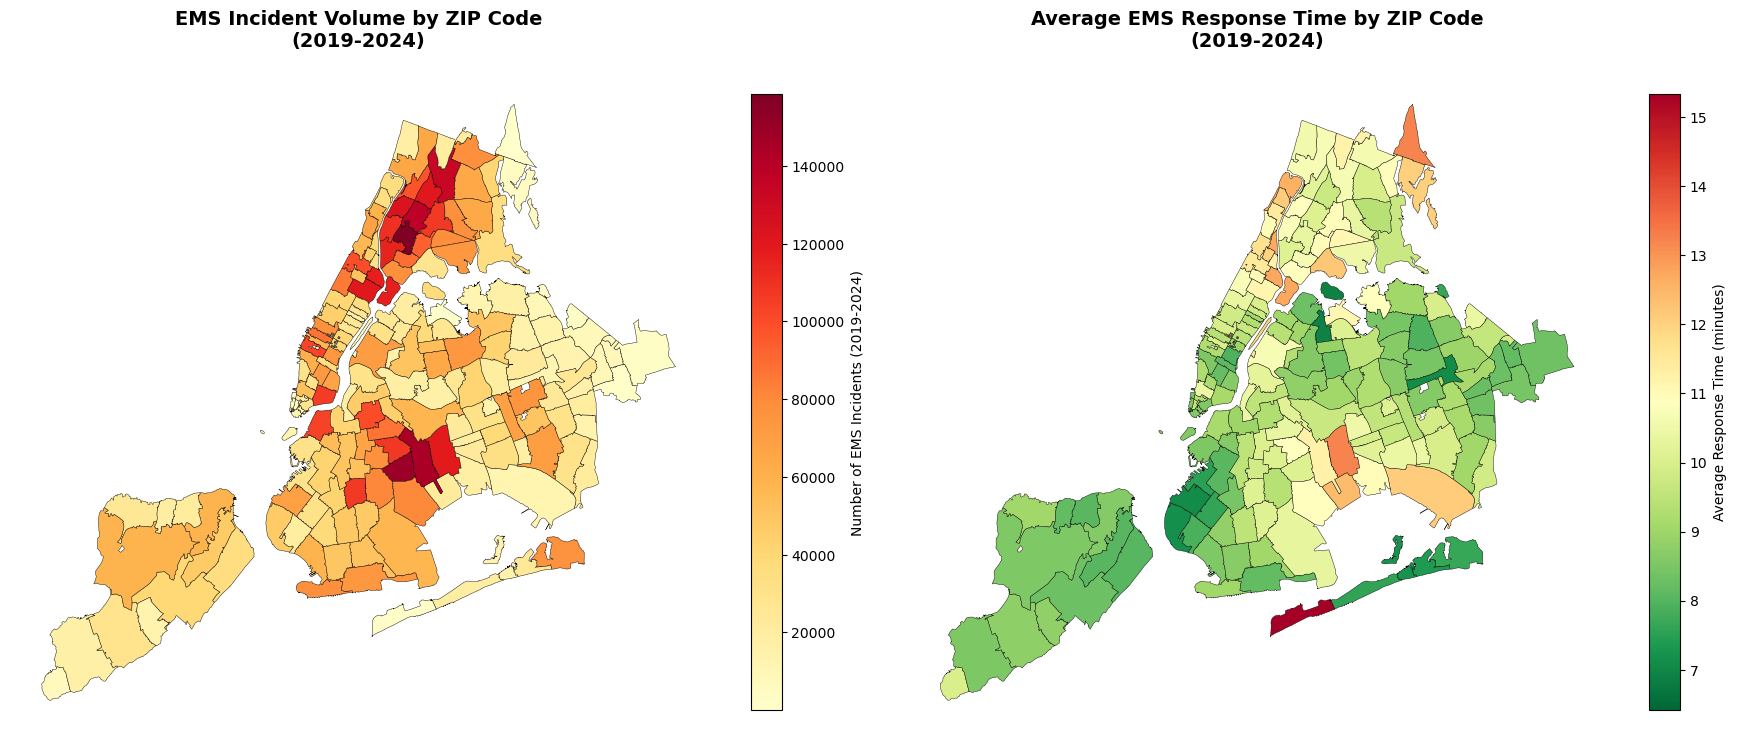

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Map 1: Incident count
gdf_final.plot(
    column='INCIDENT_COUNT',
    cmap='YlOrRd',
    legend=True,
    ax=axes[0],
    edgecolor='black',
    linewidth=0.3,
    legend_kwds={'label': "Number of EMS Incidents (2019-2024)", 'shrink': 0.8}
)
axes[0].set_title('EMS Incident Volume by ZIP Code\n(2019-2024)', 
                  fontsize=14, fontweight='bold', pad=20)
axes[0].axis('off')

# Map 2: Average response time
gdf_final.plot(
    column='AVG_RESPONSE_MIN',
    cmap='RdYlGn_r',
    legend=True,
    ax=axes[1],
    edgecolor='black',
    linewidth=0.3,
    legend_kwds={'label': "Average Response Time (minutes)", 'shrink': 0.8}
)
axes[1].set_title('Average EMS Response Time by ZIP Code\n(2019-2024)', 
                  fontsize=14, fontweight='bold', pad=20)
axes[1].axis('off')

plt.tight_layout()
plt.savefig(os.path.join(desktop_path, "ems_maps.png"), dpi=300, bbox_inches='tight')
plt.show()

## 3.3 Response Time Distribution

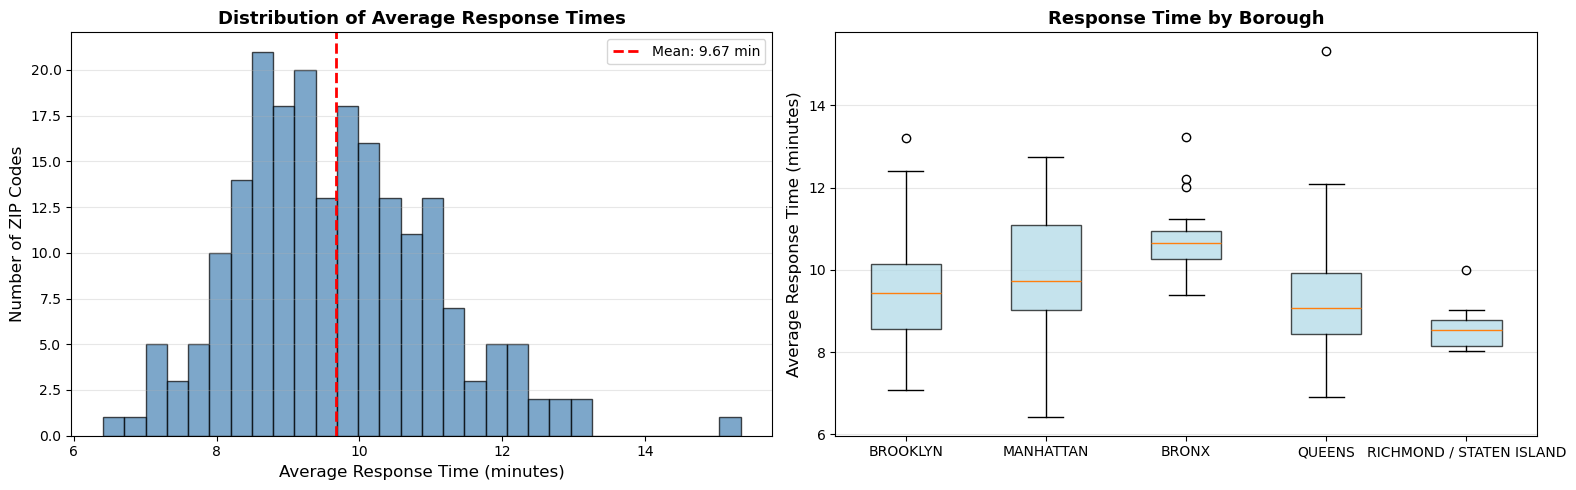

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Histogram
axes[0].hist(gdf_final['AVG_RESPONSE_MIN'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].axvline(gdf_final['AVG_RESPONSE_MIN'].mean(), color='red', linestyle='--', linewidth=2, 
                label=f"Mean: {gdf_final['AVG_RESPONSE_MIN'].mean():.2f} min")
axes[0].set_xlabel('Average Response Time (minutes)', fontsize=12)
axes[0].set_ylabel('Number of ZIP Codes', fontsize=12)
axes[0].set_title('Distribution of Average Response Times', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Box plot by borough
borough_order = gdf_final.groupby('BOROUGH')['INCIDENT_COUNT'].sum().sort_values(ascending=False).index
box_data = [gdf_final[gdf_final['BOROUGH'] == b]['AVG_RESPONSE_MIN'].values for b in borough_order]
bp = axes[1].boxplot(box_data, labels=borough_order, patch_artist=True)

for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
    patch.set_alpha(0.7)

axes[1].set_ylabel('Average Response Time (minutes)', fontsize=12)
axes[1].set_title('Response Time by Borough', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(desktop_path, "response_time_distribution.png"), dpi=300, bbox_inches='tight')
plt.show()

---

# Part 4: Advanced Spatial Analysis

## 4.1 Create Spatial Weights Matrix

In [14]:
print("="*80)
print("SPATIAL WEIGHTS MATRIX")
print("="*80)

# K-Nearest Neighbors
k = 8
spatial_weights = weights.KNN.from_dataframe(gdf_final, k=k)

print(f"Method: K-Nearest Neighbors (k={k})")
print(f"Number of observations: {spatial_weights.n}")
print(f"Average neighbors: {spatial_weights.mean_neighbors:.2f}")

SPATIAL WEIGHTS MATRIX
Method: K-Nearest Neighbors (k=8)
Number of observations: 209
Average neighbors: 8.00


## 4.2 Global Moran's I

In [15]:
print("="*80)
print("GLOBAL MORAN'S I ANALYSIS")
print("="*80)

variables_to_analyze = [
    'INCIDENT_COUNT',
    'AVG_RESPONSE_MIN',
    'median_household_income',
    'poverty_rate',
    'unemployment_rate'
]

moran_results = {}

for var in variables_to_analyze:
    y = gdf_final[var].fillna(gdf_final[var].median())
    moran = esda.Moran(y, spatial_weights)
    moran_results[var] = moran
    
    print(f"\n{var}:")
    print(f"  Moran's I:  {moran.I:.4f}")
    print(f"  P-value:    {moran.p_norm:.4f}")
    print(f"  Z-score:    {moran.z_norm:.4f}")
    
    if moran.p_norm < 0.05:
        if moran.I > 0:
            print(f"  Result: ✓ Significant POSITIVE spatial autocorrelation (clustering)")
        else:
            print(f"  Result: ✓ Significant NEGATIVE spatial autocorrelation (dispersion)")
    else:
        print(f"  Result: No significant spatial autocorrelation")

print("\n" + "="*80)

GLOBAL MORAN'S I ANALYSIS

INCIDENT_COUNT:
  Moran's I:  0.4943
  P-value:    0.0000
  Z-score:    15.7940
  Result: ✓ Significant POSITIVE spatial autocorrelation (clustering)

AVG_RESPONSE_MIN:
  Moran's I:  0.4163
  P-value:    0.0000
  Z-score:    13.3245
  Result: ✓ Significant POSITIVE spatial autocorrelation (clustering)

median_household_income:
  Moran's I:  0.6211
  P-value:    0.0000
  Z-score:    19.8073
  Result: ✓ Significant POSITIVE spatial autocorrelation (clustering)

poverty_rate:
  Moran's I:  0.6017
  P-value:    0.0000
  Z-score:    19.1928
  Result: ✓ Significant POSITIVE spatial autocorrelation (clustering)

unemployment_rate:
  Moran's I:  0.4823
  P-value:    0.0000
  Z-score:    15.4150
  Result: ✓ Significant POSITIVE spatial autocorrelation (clustering)



## 4.3 Local Moran's I (LISA)

In [16]:
print("="*80)
print("LOCAL MORAN'S I (LISA) ANALYSIS")
print("="*80)

lisa_vars = ['INCIDENT_COUNT', 'AVG_RESPONSE_MIN', 'poverty_rate']
lisa_results = {}

for var in lisa_vars:
    print(f"\n{var}:")
    
    y = gdf_final[var].fillna(gdf_final[var].median())
    lisa = esda.Moran_Local(y, spatial_weights)
    
    cluster_labels = {
        1: 'HH (High-High)',
        2: 'LH (Low-High)',
        3: 'LL (Low-Low)',
        4: 'HL (High-Low)',
        0: 'Not Significant'
    }
    
    clusters = pd.Series(['Not Significant'] * len(gdf_final), index=gdf_final.index)
    for i, (q, p) in enumerate(zip(lisa.q, lisa.p_sim)):
        if p < 0.05:
            clusters.iloc[i] = cluster_labels[q]
    
    lisa_results[var] = {'lisa': lisa, 'clusters': clusters}
    gdf_final[f'{var}_lisa_cluster'] = clusters
    
    print("  LISA Cluster Distribution:")
    for cluster, count in clusters.value_counts().items():
        print(f"    {cluster}: {count}")

print("\n" + "="*80)

LOCAL MORAN'S I (LISA) ANALYSIS

INCIDENT_COUNT:
  LISA Cluster Distribution:
    Not Significant: 111
    LL (Low-Low): 51
    HH (High-High): 32
    LH (Low-High): 10
    HL (High-Low): 5

AVG_RESPONSE_MIN:
  LISA Cluster Distribution:
    Not Significant: 111
    HH (High-High): 47
    LL (Low-Low): 46
    HL (High-Low): 3
    LH (Low-High): 2

poverty_rate:
  LISA Cluster Distribution:
    Not Significant: 107
    LL (Low-Low): 53
    HH (High-High): 42
    LH (Low-High): 4
    HL (High-Low): 3



## 4.4 LISA Cluster Maps

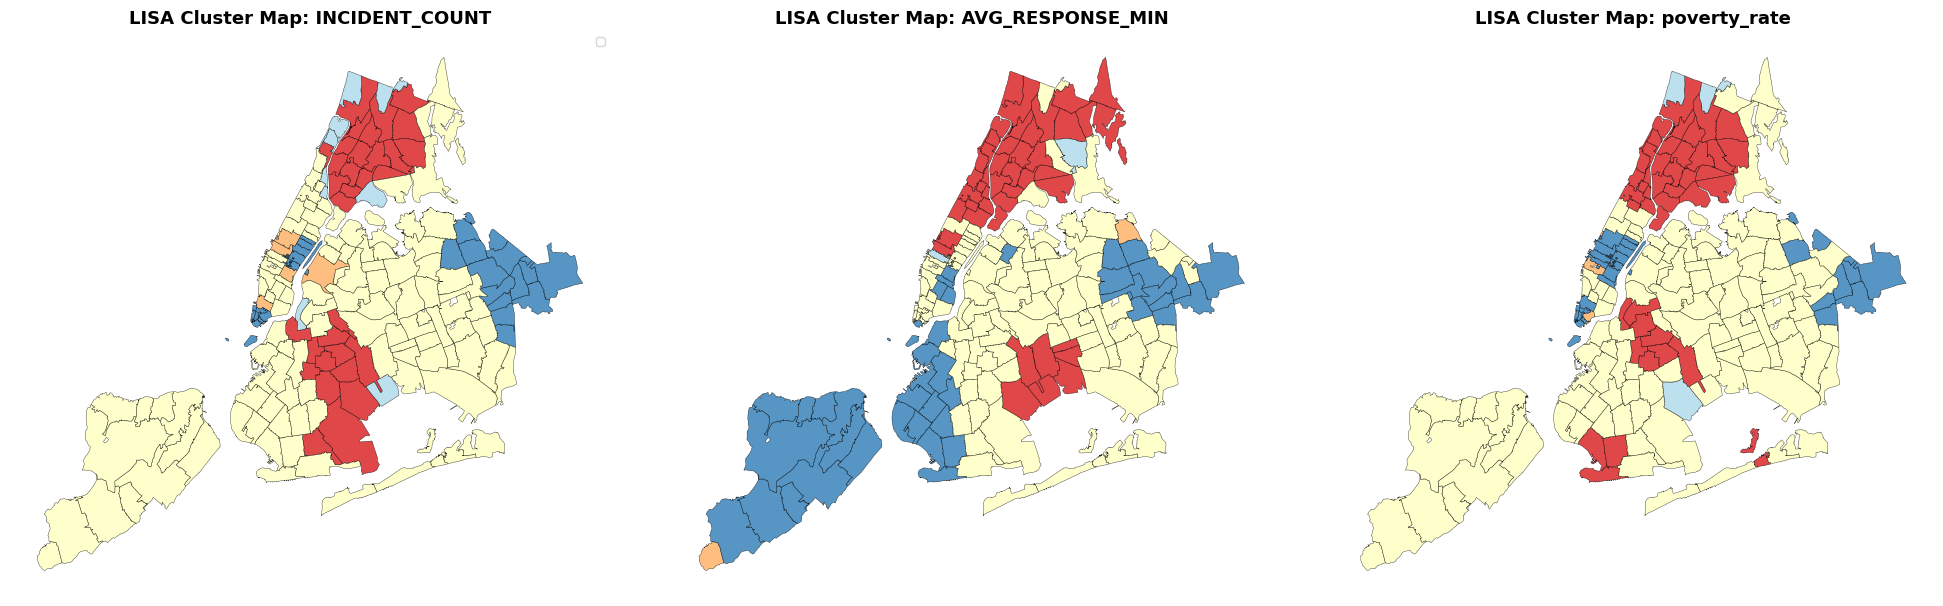

In [17]:
colors = {
    'HH (High-High)': '#d7191c',
    'HL (High-Low)': '#fdae61',
    'LH (Low-High)': '#abd9e9',
    'LL (Low-Low)': '#2c7bb6',
    'Not Significant': '#ffffbf'
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, var in enumerate(lisa_vars):
    ax = axes[idx]
    
    for cluster_type, color in colors.items():
        subset = gdf_final[gdf_final[f'{var}_lisa_cluster'] == cluster_type]
        if len(subset) > 0:
            subset.plot(ax=ax, color=color, edgecolor='black', 
                       linewidth=0.3, alpha=0.8, label=cluster_type)
    
    ax.set_title(f'LISA Cluster Map: {var}', fontsize=13, fontweight='bold')
    ax.axis('off')
    if idx == 0:
        ax.legend(loc='best', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(desktop_path, "lisa_cluster_maps.png"), dpi=300, bbox_inches='tight')
plt.show()

## 4.5 Getis-Ord Gi* Hot Spot Analysis

In [18]:
print("="*80)
print("GETIS-ORD Gi* HOT SPOT ANALYSIS")
print("="*80)

gi_vars = ['INCIDENT_COUNT', 'AVG_RESPONSE_MIN', 'poverty_rate']
gi_results = {}

def classify_hotspot(z_score, p_value):
    if p_value > 0.05:
        return 'Not Significant'
    elif z_score > 2.58:
        return 'Hot Spot (99%)'
    elif z_score > 1.96:
        return 'Hot Spot (95%)'
    elif z_score > 1.65:
        return 'Hot Spot (90%)'
    elif z_score < -2.58:
        return 'Cold Spot (99%)'
    elif z_score < -1.96:
        return 'Cold Spot (95%)'
    elif z_score < -1.65:
        return 'Cold Spot (90%)'
    else:
        return 'Not Significant'

for var in gi_vars:
    print(f"\n{var}:")
    
    y = gdf_final[var].fillna(gdf_final[var].median())
    
    # FIXED: Use G_Local with permutations=0 to avoid numba issues
    getis_ord = esda.G_Local(y, spatial_weights, permutations=0)
    
    # Use p_norm (normal approximation) instead of p_sim
    hotspots = pd.Series([classify_hotspot(z, p) for z, p in zip(getis_ord.Zs, getis_ord.p_norm)],
                         index=gdf_final.index)
    
    gi_results[var] = {'gi': getis_ord, 'hotspots': hotspots}
    gdf_final[f'{var}_gi_star'] = getis_ord.Zs
    gdf_final[f'{var}_hotspot'] = hotspots
    
    print("  Hot/Cold Spot Distribution:")
    for hotspot, count in hotspots.value_counts().items():
        print(f"    {hotspot}: {count}")

print("\n" + "="*80)

GETIS-ORD Gi* HOT SPOT ANALYSIS

INCIDENT_COUNT:
  Hot/Cold Spot Distribution:
    Not Significant: 207
    Hot Spot (95%): 1
    Hot Spot (90%): 1

AVG_RESPONSE_MIN:
  Hot/Cold Spot Distribution:
    Not Significant: 209

poverty_rate:
  Hot/Cold Spot Distribution:
    Not Significant: 202
    Hot Spot (95%): 4
    Hot Spot (90%): 3



## 4.6 Hot Spot Maps

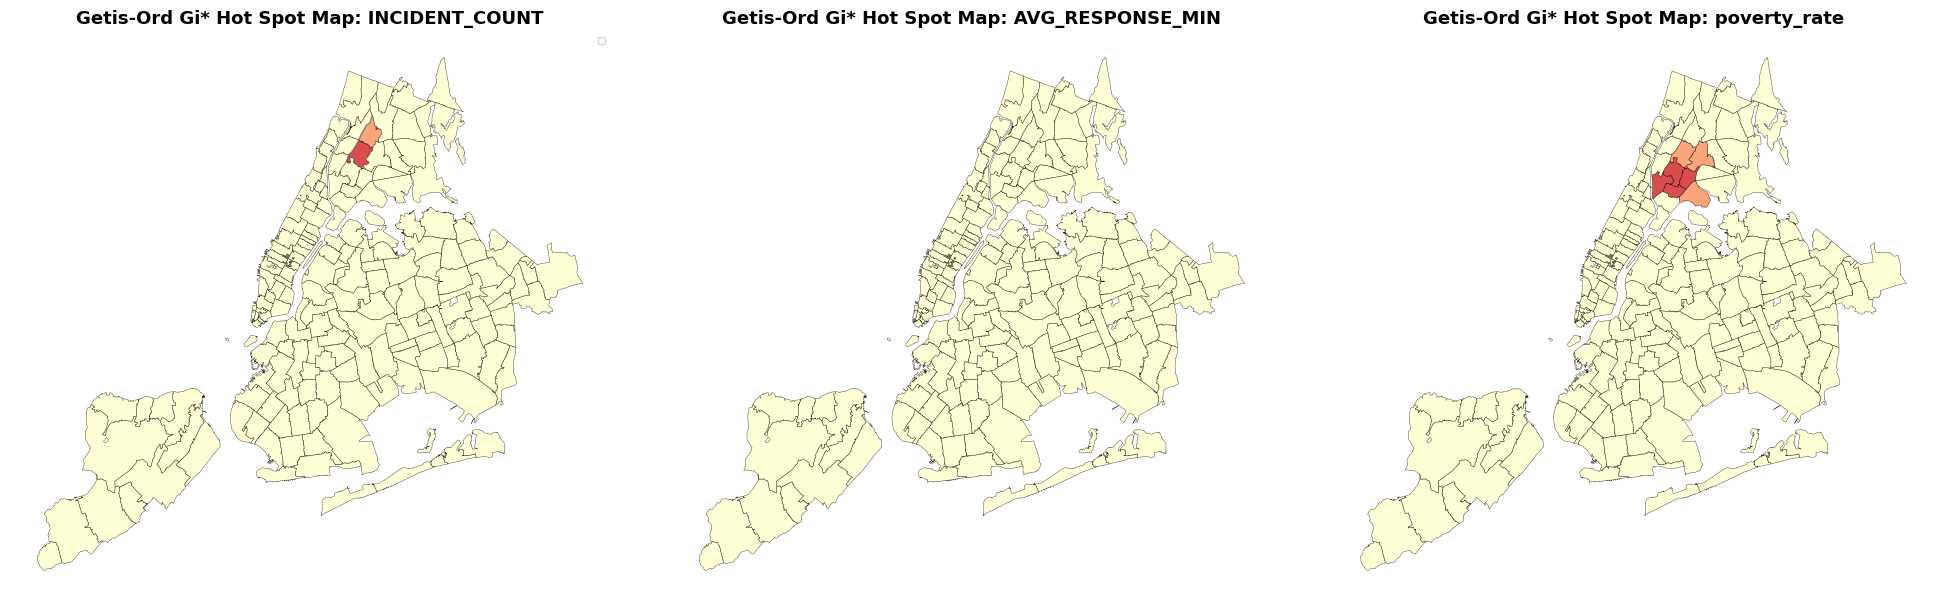

In [19]:
hotspot_colors = {
    'Hot Spot (99%)': '#67000d',
    'Hot Spot (95%)': '#d32020',
    'Hot Spot (90%)': '#fc8d59',
    'Not Significant': '#ffffcc',
    'Cold Spot (90%)': '#91bfdb',
    'Cold Spot (95%)': '#4575b4',
    'Cold Spot (99%)': '#08306b'
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, var in enumerate(gi_vars):
    ax = axes[idx]
    
    for hotspot_type, color in hotspot_colors.items():
        subset = gdf_final[gdf_final[f'{var}_hotspot'] == hotspot_type]
        if len(subset) > 0:
            subset.plot(ax=ax, color=color, edgecolor='black', 
                       linewidth=0.3, alpha=0.8, label=hotspot_type)
    
    ax.set_title(f'Getis-Ord Gi* Hot Spot Map: {var}', fontsize=13, fontweight='bold')
    ax.axis('off')
    if idx == 0:
        ax.legend(loc='best', fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(desktop_path, "hotspot_maps.png"), dpi=300, bbox_inches='tight')
plt.show()

## 4.7 Save Final Dataset with Spatial Analysis

In [20]:
# Save complete dataset with all analysis results
final_csv_path = os.path.join(desktop_path, "nyc_ems_final_with_spatial_analysis.csv")
gdf_final.drop(columns='geometry').to_csv(final_csv_path, index=False)
print(f"✓ Final CSV saved: {final_csv_path}")

final_geojson_path = os.path.join(desktop_path, "nyc_ems_final_spatial.geojson")
gdf_final.to_file(final_geojson_path, driver='GeoJSON')
print(f"✓ Final GeoJSON saved: {final_geojson_path}")

print(f"\nFinal dataset includes:")
print(f"  - {len(gdf_final)} ZIP codes")
print(f"  - {len(gdf_final.columns)} total columns")
print(f"  - EMS metrics")
print(f"  - Socioeconomic variables (ACS)")
print(f"  - Spatial analysis results (Moran's I, LISA, Gi*)")
print(f"\n✓ Ready for machine learning analysis!")

✓ Final CSV saved: /Users/alex._choo/Desktop/nyc_ems_final_with_spatial_analysis.csv
✓ Final GeoJSON saved: /Users/alex._choo/Desktop/nyc_ems_final_spatial.geojson

Final dataset includes:
  - 209 ZIP codes
  - 43 total columns
  - EMS metrics
  - Socioeconomic variables (ACS)
  - Spatial analysis results (Moran's I, LISA, Gi*)

✓ Ready for machine learning analysis!


---

# Next Steps: Machine Learning

The dataset is now ready for machine learning analysis:

1. **Feature Engineering**: Create additional features from temporal data
2. **Regression Models**: Predict EMS response times
3. **Classification Models**: Predict on-time vs delayed responses
4. **Fairness Analysis**: Examine residual disparities by socioeconomic groups
5. **Model Interpretability**: SHAP values and feature importance

See the project plan for detailed implementation steps.

## 5.1 Feature Engineering

In [21]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier

from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
)

import seaborn as sns 

In [22]:
df = pd.read_csv("nyc_ems_final_with_spatial_analysis.csv")
print(df.shape)
df.head()

(209, 42)


,ZIPCODE,GEOID20,CLASSFP20,MTFCC20,FUNCSTAT20,ALAND20,AWATER20,INTPTLAT20,INTPTLON20,INCIDENT_COUNT,AVG_RESPONSE_SEC,BOROUGH,AVG_RESPONSE_MIN,total_population,total_households,median_age,median_household_income,median_home_value,median_gross_rent,poverty_rate,unemployment_rate,college_degree_rate,graduate_degree_rate,renter_rate,pct_white,pct_black,pct_asian,pct_hispanic,pct_native_american,pct_pacific_islander,pct_other_race,pct_two_or_more_races,diversity_index,INCIDENT_COUNT_lisa_cluster,AVG_RESPONSE_MIN_lisa_cluster,poverty_rate_lisa_cluster,INCIDENT_COUNT_gi_star,INCIDENT_COUNT_hotspot,AVG_RESPONSE_MIN_gi_star,AVG_RESPONSE_MIN_hotspot,poverty_rate_gi_star,poverty_rate_hotspot
0,10152,10152,B5,G6350,S,12423,0,40.758404,-73.972031,41,654.390244,MANHATTAN,10.906504,0,0,-666666666.0,-666666666,-666666666,-666666666,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,LL (Low-Low),Not Significant,LL (Low-Low),-1.009278,Not Significant,-0.141411,Not Significant,-1.288505,Not Significant
1,10153,10153,B5,G6350,S,12281,0,40.763622,-73.972439,340,669.932353,MANHATTAN,11.165539,0,0,-666666666.0,-666666666,-666666666,-666666666,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,LL (Low-Low),HH (High-High),LL (Low-Low),-1.006369,Not Significant,0.889988,Not Significant,-1.288505,Not Significant
2,10168,10168,B5,G6350,S,13211,0,40.751448,-73.977103,797,464.590966,MANHATTAN,7.743183,0,0,-666666666.0,-666666666,-666666666,-666666666,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,LL (Low-Low),LL (Low-Low),LL (Low-Low),-1.011478,Not Significant,-0.748512,Not Significant,-1.269186,Not Significant
3,11229,11229,B5,G6350,S,5199254,143662,40.601293,-73.944493,50938,542.409694,BROOKLYN,9.040162,81109,30751,42.2,72799,809600,1586,15.682442,4.494858,41.389666,16.935901,51.656857,60.578974,6.249615,24.042955,8.831326,0.239184,0.069043,3.702425,5.117804,0.559511,Not Significant,Not Significant,Not Significant,0.602056,Not Significant,-0.200891,Not Significant,0.224434,Not Significant
4,11363,11363,B5,G6350,S,2239195,34217,40.772348,-73.746292,2801,623.922528,QUEENS,10.398709,7365,2855,46.3,112625,986000,2334,8.920570,6.238435,56.375962,27.647490,28.861646,55.016972,0.624576,30.902919,12.423625,0.868975,0.000000,1.520706,11.065852,0.573789,LL (Low-Low),Not Significant,LL (Low-Low),-0.854549,Not Significant,-0.473629,Not Significant,-0.711240,Not Significant


In [23]:
df.columns

Index(['ZIPCODE', 'GEOID20', 'CLASSFP20', 'MTFCC20', 'FUNCSTAT20', 'ALAND20', 'AWATER20',
       'INTPTLAT20', 'INTPTLON20', 'INCIDENT_COUNT', 'AVG_RESPONSE_SEC', 'BOROUGH',
       'AVG_RESPONSE_MIN', 'total_population', 'total_households', 'median_age',
       'median_household_income', 'median_home_value', 'median_gross_rent', 'poverty_rate',
       'unemployment_rate', 'college_degree_rate', 'graduate_degree_rate', 'renter_rate',
       'pct_white', 'pct_black', 'pct_asian', 'pct_hispanic', 'pct_native_american',
       'pct_pacific_islander', 'pct_other_race', 'pct_two_or_more_races', 'diversity_index',
       'INCIDENT_COUNT_lisa_cluster', 'AVG_RESPONSE_MIN_lisa_cluster', 'poverty_rate_lisa_cluster',
       'INCIDENT_COUNT_gi_star', 'INCIDENT_COUNT_hotspot', 'AVG_RESPONSE_MIN_gi_star',
       'AVG_RESPONSE_MIN_hotspot', 'poverty_rate_gi_star', 'poverty_rate_hotspot'],
      dtype='object')

In [24]:
df = df.copy()  # work on a copy to be safe

# calls per 1000 residents 
df["incidents_per_1000"] = (df["INCIDENT_COUNT"] / df["total_population"]) * 1000

#response inefficiency - minutes per incident 
df["response_time_per_incident"] = df["AVG_RESPONSE_MIN"] / df["INCIDENT_COUNT"]

#binary hotspot - 1 if Hotspot, 0 otherwise
df["is_hotspot"] = (df["INCIDENT_COUNT_hotspot"] == "Hotspot").astype(int)

#boroughs encoded numerically 
df["borough_encoded"] = df["BOROUGH"].astype("category").cat.codes

## 5.2 Logistic Regression 


In [25]:
y = (df["AVG_RESPONSE_MIN"] > 10).astype(int)

drop_cols = [
    "ZIPCODE",
    "BOROUGH",
    "AVG_RESPONSE_MIN",  # target
    "GEOID20",
    "ALAND20",
    "AWATER20",
    "INTPTLAT20",
    "INTPTLON20",
    "INCIDENT_COUNT_gi_star",
    "AVG_RESPONSE_MIN_gi_star",
    "poverty_rate_gi_star",
    "AVG_RESPONSE_SEC",
    "response_time_per_incident",
]

X = df.drop(columns=drop_cols, errors="ignore")
#keep numeric columns 
X = X.select_dtypes(include=[np.number])
#replace inf/-inf with NaN 
X = X.replace([np.inf, -np.inf], np.nan)

print("NaNs in X BEFORE impute:", X.isna().sum().sum())  # just to see

nan_mask = ~X.isna().any(axis=1)
X = X[nan_mask].copy()
y = y[nan_mask].copy()   # <-- IMPORTANT: drop same rows in y

print("NaNs in X AFTER dropping:", X.isna().sum().sum())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


NaNs in X BEFORE impute: 24
NaNs in X AFTER dropping: 0


In [26]:
print("Numeric columns kept in X:")
print(X.columns.tolist())

X.isna().sum()[X.isna().sum() > 0]

print("Original df:", df.shape)
print("After numeric-select:", X.shape)


Numeric columns kept in X:
['INCIDENT_COUNT', 'total_population', 'total_households', 'median_age', 'median_household_income', 'median_home_value', 'median_gross_rent', 'poverty_rate', 'unemployment_rate', 'college_degree_rate', 'graduate_degree_rate', 'renter_rate', 'pct_white', 'pct_black', 'pct_asian', 'pct_hispanic', 'pct_native_american', 'pct_pacific_islander', 'pct_other_race', 'pct_two_or_more_races', 'diversity_index', 'incidents_per_1000', 'is_hotspot', 'borough_encoded']
Original df: (209, 46)
After numeric-select: (185, 24)


In [27]:
param_grid_lg = [
    {'penalty': ['l2'],
     'C': [0.01, 0.1, 1, 10, 100],
     'solver': ['lbfgs', 'liblinear', 'saga'],
     'max_iter': [1000]},
    {'penalty': ['l1'],
     'C': [0.01, 0.1, 1, 10, 100],
     'solver': ['liblinear', 'saga'],
     'max_iter': [1000]},
]

log_reg = LogisticRegression()

lg_grid = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_grid_lg,
    n_iter=25,
    scoring='roc_auc',
    cv=5,           # k-fold CV on the TRAIN set
    n_jobs=-1,
    random_state=0,
    verbose=1
)

lg_grid.fit(X_train_scaled, y_train)
print("Best params (RandomizedSearchCV):", lg_grid.best_params_)

lgmodel = lg_grid.best_estimator_

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params (RandomizedSearchCV): {'solver': 'saga', 'penalty': 'l1', 'max_iter': 1000, 'C': 1}


Training AUC: 0.8975571315996848
Test AUC: 0.8525641025641025


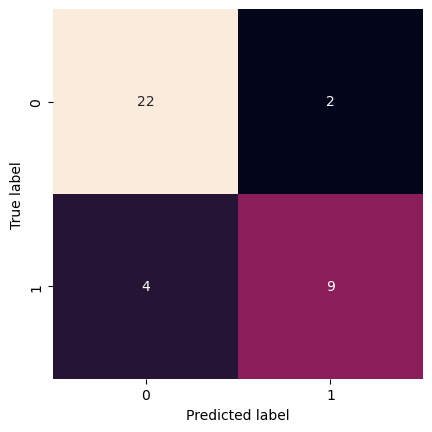

In [28]:
train_proba = lgmodel.predict_proba(X_train_scaled)[:, 1]
train_auc = metrics.roc_auc_score(y_train, train_proba)
print("Training AUC:", train_auc)

# Test predictions (always use X_test_scaled!)
y_test_proba = lgmodel.predict_proba(X_test_scaled)[:, 1]
y_test_pred  = lgmodel.predict(X_test_scaled)

test_auc = metrics.roc_auc_score(y_test, y_test_proba)
print("Test AUC:", test_auc)

# Confusion matrix
cm = metrics.confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, square=True, annot=True, fmt='d', cbar=False)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

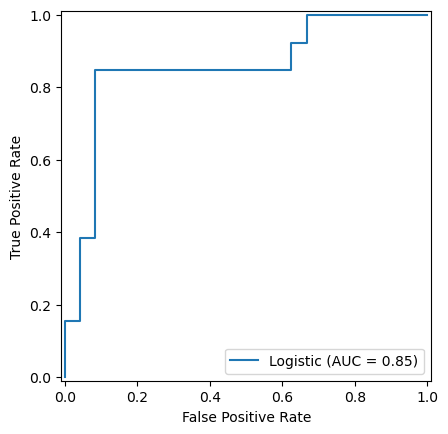

In [29]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_test_proba)
roc_auc = metrics.auc(fpr, tpr)

metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                        estimator_name='Logistic').plot()
plt.show()

## 5.3 Non-Logistic Regression (GradientBoostingClassifier)


In [30]:
# Target: delayed responses (AVG_RESPONSE_MIN > 10 minutes)
y = (df["AVG_RESPONSE_MIN"] > 10).astype(int)

# Columns to drop (IDs, geometry, and target-derived / leakage)
drop_cols = [
    "ZIPCODE",
    "BOROUGH",
    "AVG_RESPONSE_MIN",  # target
    "GEOID20",
    "ALAND20",
    "AWATER20",
    "INTPTLAT20",
    "INTPTLON20",
    "INCIDENT_COUNT_gi_star",
    "AVG_RESPONSE_MIN_gi_star",
    "poverty_rate_gi_star",
    "AVG_RESPONSE_SEC",
    "response_time_per_incident",
]

X = df.drop(columns=drop_cols, errors="ignore")
# Keep only numeric features for sklearn (you can add encoded categorical manually if desired)
X = X.select_dtypes(include=[np.number])

# Replace infinite values with NaN (safeguard)
X = X.replace([np.inf, -np.inf], np.nan)

print("Candidate numeric feature count:", X.shape[1])
print("Columns:", X.columns.tolist())

Candidate numeric feature count: 24
Columns: ['INCIDENT_COUNT', 'total_population', 'total_households', 'median_age', 'median_household_income', 'median_home_value', 'median_gross_rent', 'poverty_rate', 'unemployment_rate', 'college_degree_rate', 'graduate_degree_rate', 'renter_rate', 'pct_white', 'pct_black', 'pct_asian', 'pct_hispanic', 'pct_native_american', 'pct_pacific_islander', 'pct_other_race', 'pct_two_or_more_races', 'diversity_index', 'incidents_per_1000', 'is_hotspot', 'borough_encoded']


In [31]:
# Handing missing values by dropping rows with any NaNs
nan_mask = ~X.isna().any(axis=1)
X = X[nan_mask].copy()
y = y[nan_mask].copy()

print("After dropping rows with NaN -> X shape:", X.shape, "y shape:", y.shape)
print("NaNs in X AFTER dropping:", X.isna().sum().sum())

After dropping rows with NaN -> X shape: (185, 24) y shape: (185,)
NaNs in X AFTER dropping: 0


In [32]:
# Train-test split 80/20 ratio (stratify to preserve class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=0, stratify=y
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)

X_train: (148, 24) X_test: (37, 24)


In [33]:
# GradientBoostingClassifier + RandomizedSearchCV for hyperparameter tuning
gbm = GradientBoostingClassifier(random_state=0)

param_distributions = {
    'n_estimators': [50, 100, 200, 400],
    'learning_rate': [0.001, 0.01, 0.05, 0.1],
    'max_depth': [1, 2, 3, 4, 6],
    'subsample': [0.6, 0.8, 1.0],
    'max_features': [None, 'sqrt', 'log2', 0.5],
    'min_samples_split': [2, 5, 10],
}

rand_search = RandomizedSearchCV(
    estimator=gbm,
    param_distributions=param_distributions,
    n_iter=25,               # number of sampled candidates (tune this)
    scoring='roc_auc',       # optimize for AUC
    cv=5,
    n_jobs=-1,
    random_state=0,
    verbose=1
)

# Fit on training data (this does the CV and hyperparameter search)
rand_search.fit(X_train, y_train)

print("Best params found by RandomizedSearchCV:")
print(rand_search.best_params_)

best_gbm = rand_search.best_estimator_

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best params found by RandomizedSearchCV:
{'subsample': 1.0, 'n_estimators': 100, 'min_samples_split': 5, 'max_features': 'log2', 'max_depth': 6, 'learning_rate': 0.1}


In [34]:
## Evaluate best_gbm on train and test sets with requested metrics

# Training AUC (probabilities)
train_proba = best_gbm.predict_proba(X_train)[:, 1]
train_auc = metrics.roc_auc_score(y_train, train_proba)
print("Training AUC:", train_auc)

# Test AUC, predictions and other metrics
test_proba = best_gbm.predict_proba(X_test)[:, 1]
y_test_pred = best_gbm.predict(X_test)

test_auc = metrics.roc_auc_score(y_test, test_proba)
acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, zero_division=0)
rec = recall_score(y_test, y_test_pred, zero_division=0)
f1 = f1_score(y_test, y_test_pred, zero_division=0)

print(f"Test AUC: {test_auc:.4f}")
print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")

Training AUC: 1.0
Test AUC: 0.9071
Accuracy: 0.8108 | Precision: 0.8000 | Recall: 0.6154 | F1: 0.6957


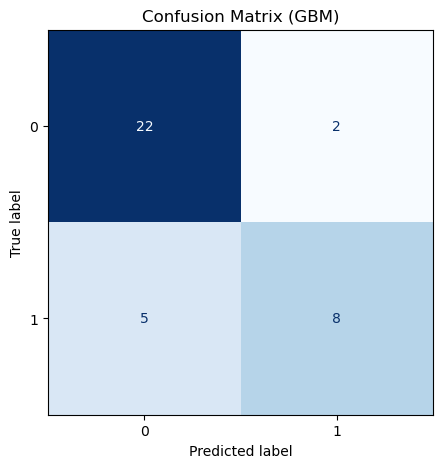

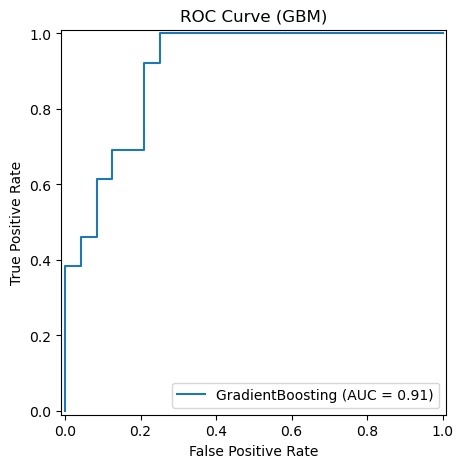

In [35]:
# Confusion matrix and ROC curve (visual)

cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_gbm.classes_)
fig, ax = plt.subplots(figsize=(6,5))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix (GBM)")
plt.show()

# ROC curve (use probabilities)
fpr, tpr, _ = metrics.roc_curve(y_test, test_proba)
roc_disp = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=test_auc, estimator_name="GradientBoosting")
fig, ax = plt.subplots(figsize=(6,5))
roc_disp.plot(ax=ax)
plt.title("ROC Curve (GBM)")
plt.show()

Top 20 feature importances:
pct_asian                  0.096277
pct_white                  0.087610
pct_hispanic               0.078297
pct_other_race             0.073979
pct_black                  0.069799
renter_rate                0.058224
poverty_rate               0.056449
unemployment_rate          0.046436
median_gross_rent          0.043011
borough_encoded            0.041521
incidents_per_1000         0.039133
median_household_income    0.039092
median_home_value          0.038318
pct_two_or_more_races      0.035826
diversity_index            0.034226
INCIDENT_COUNT             0.027363
total_population           0.027340
median_age                 0.021670
pct_native_american        0.020697
graduate_degree_rate       0.020246
dtype: float64


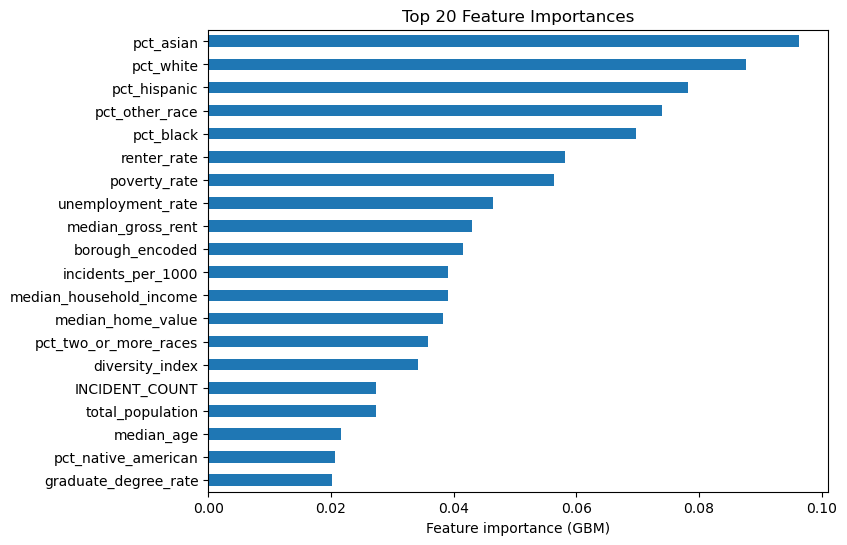

In [36]:
# Feature importances (simple built-in measure for GBM)
importances = pd.Series(best_gbm.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)
print("Top 20 feature importances:")
print(importances.head(20))

# Optional bar plot for top features
fig, ax = plt.subplots(figsize=(8,6))
importances.head(20).plot.barh(ax=ax)
ax.invert_yaxis()
plt.xlabel("Feature importance (GBM)")
plt.title("Top 20 Feature Importances")
plt.show()

## 5.4 Non-Logistic Regression (Random Forest Classifier)


In [37]:
# Target: delayed responses (AVG_RESPONSE_MIN > 10 minutes)
y = (df["AVG_RESPONSE_MIN"] > 10).astype(int)

# Columns to drop (IDs, geometry, and target-derived / leakage)
drop_cols = [
    "ZIPCODE",
    "BOROUGH",
    "AVG_RESPONSE_MIN",  # target
    "GEOID20",
    "ALAND20",
    "AWATER20",
    "INTPTLAT20",
    "INTPTLON20",
    "INCIDENT_COUNT_gi_star",
    "AVG_RESPONSE_MIN_gi_star",
    "poverty_rate_gi_star",
    "AVG_RESPONSE_SEC",
    "response_time_per_incident",
]

X = df.drop(columns=drop_cols, errors="ignore")
# Keep only numeric features for sklearn (you can add encoded categorical manually if desired)
X = X.select_dtypes(include=[np.number])

# Replace infinite values with NaN (safeguard)
X = X.replace([np.inf, -np.inf], np.nan)

print("Candidate numeric feature count:", X.shape[1])
print("Columns:", X.columns.tolist())

Candidate numeric feature count: 24
Columns: ['INCIDENT_COUNT', 'total_population', 'total_households', 'median_age', 'median_household_income', 'median_home_value', 'median_gross_rent', 'poverty_rate', 'unemployment_rate', 'college_degree_rate', 'graduate_degree_rate', 'renter_rate', 'pct_white', 'pct_black', 'pct_asian', 'pct_hispanic', 'pct_native_american', 'pct_pacific_islander', 'pct_other_race', 'pct_two_or_more_races', 'diversity_index', 'incidents_per_1000', 'is_hotspot', 'borough_encoded']


In [38]:
# Handing missing values by dropping rows with any NaNs
nan_mask = ~X.isna().any(axis=1)
X = X[nan_mask].copy()
y = y[nan_mask].copy()

print("After dropping rows with NaN -> X shape:", X.shape, "y shape:", y.shape)
print("NaNs in X AFTER dropping:", X.isna().sum().sum())

After dropping rows with NaN -> X shape: (185, 24) y shape: (185,)
NaNs in X AFTER dropping: 0


In [39]:
# Train-test split 80/20 ratio (stratify to preserve class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=0, stratify=y
)

print("X_train:", X_train.shape, "X_test:", X_test.shape)

X_train: (148, 24) X_test: (37, 24)


In [40]:
# RandomForestClassifier + RandomizedSearchCV (hyperparameter tuning)
rf = RandomForestClassifier(random_state=0)

param_distributions = {
    'n_estimators': [100, 200, 400, 800],
    'max_depth': [None, 5, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'max_features': ['auto', 'sqrt', 'log2', 0.5],
    'bootstrap': [True, False]
}

rand_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_distributions,
    n_iter=30,              # number of randomly sampled hyperparam settings
    scoring='roc_auc',      # optimize AUC
    cv=5,
    n_jobs=-1,
    random_state=0,
    verbose=1
)

# Fit on training data (performs cross-validation)
rand_search.fit(X_train, y_train)

print("Best params (RandomizedSearchCV):")
print(rand_search.best_params_)
best_rf = rand_search.best_estimator_

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params (RandomizedSearchCV):
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': 30, 'bootstrap': False}


In [41]:
## Evaluate the best model on train and test

# Train AUC (probabilities)
train_proba = best_rf.predict_proba(X_train)[:, 1]
train_auc = metrics.roc_auc_score(y_train, train_proba)
print("Training AUC:", train_auc)

# Test: probabilities + predictions
test_proba = best_rf.predict_proba(X_test)[:, 1]
y_test_pred = best_rf.predict(X_test)

test_auc = metrics.roc_auc_score(y_test, test_proba)
acc = accuracy_score(y_test, y_test_pred)
prec = precision_score(y_test, y_test_pred, zero_division=0)
rec = recall_score(y_test, y_test_pred, zero_division=0)
f1 = f1_score(y_test, y_test_pred, zero_division=0)

print(f"Test AUC: {test_auc:.4f}")
print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")

Training AUC: 1.0
Test AUC: 0.8526
Accuracy: 0.8108 | Precision: 0.8000 | Recall: 0.6154 | F1: 0.6957


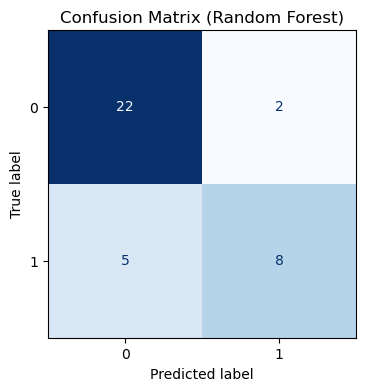

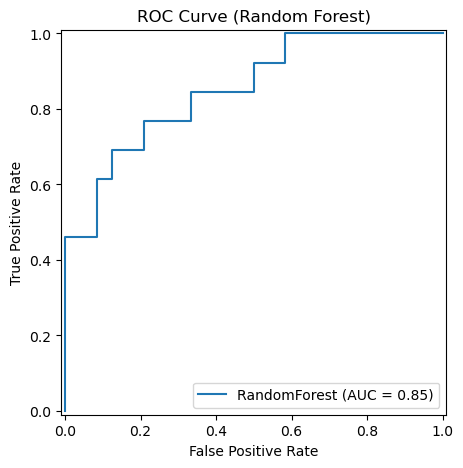

In [42]:
# Confusion matrix and ROC curve
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf.classes_)
fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix (Random Forest)")
plt.show()

# ROC curve using probabilities
fpr, tpr, _ = metrics.roc_curve(y_test, test_proba)
roc_disp = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=test_auc, estimator_name="RandomForest")
fig, ax = plt.subplots(figsize=(6,5))
roc_disp.plot(ax=ax)
plt.title("ROC Curve (Random Forest)")
plt.show()

Top 20 feature importances:
pct_asian                  0.177659
pct_black                  0.119946
borough_encoded            0.066467
pct_other_race             0.055486
pct_hispanic               0.050661
median_household_income    0.050189
unemployment_rate          0.045013
pct_two_or_more_races      0.044512
median_home_value          0.041836
pct_white                  0.041229
median_age                 0.038873
renter_rate                0.037907
diversity_index            0.032126
poverty_rate               0.024760
total_households           0.024187
total_population           0.023413
INCIDENT_COUNT             0.020763
graduate_degree_rate       0.019526
pct_native_american        0.019340
median_gross_rent          0.018731
dtype: float64


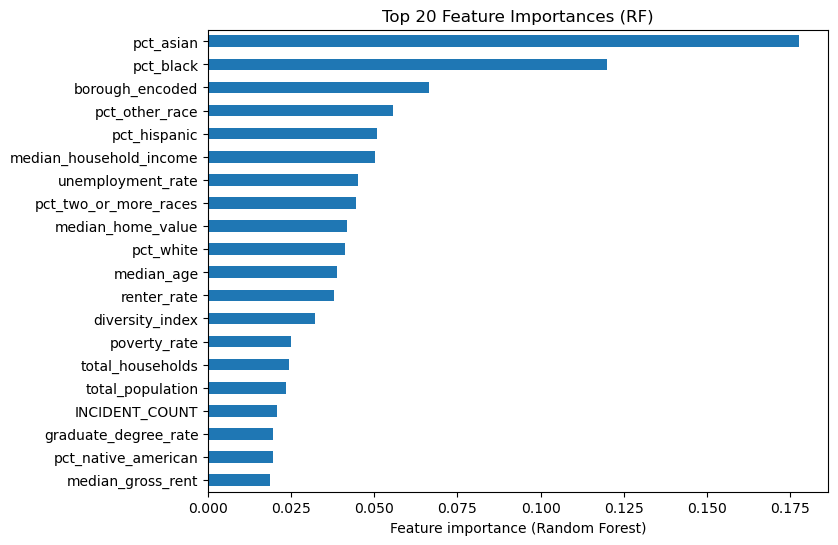

In [43]:
# Feature importances
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top 20 feature importances:")
print(importances.head(20))

# Bar plot of top features
fig, ax = plt.subplots(figsize=(8,6))
importances.head(20).plot.barh(ax=ax)
ax.invert_yaxis()
plt.xlabel("Feature importance (Random Forest)")
plt.title("Top 20 Feature Importances (RF)")
plt.show()

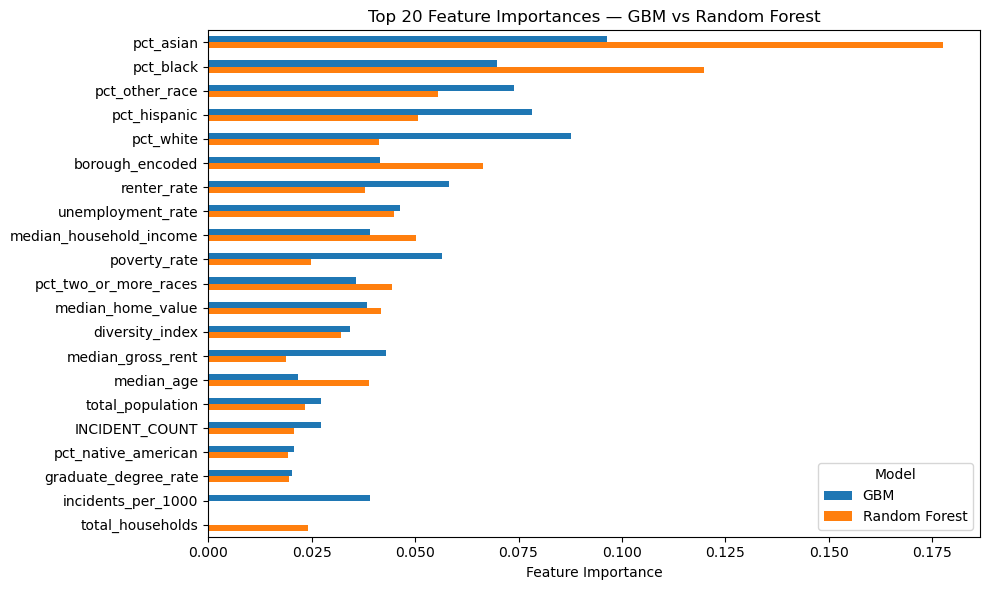

,GBM,Random Forest,Average
pct_asian,0.096277,0.177659,0.136968
pct_black,0.069799,0.119946,0.094873
pct_other_race,0.073979,0.055486,0.064733
pct_hispanic,0.078297,0.050661,0.064479
pct_white,0.087610,0.041229,0.064419
borough_encoded,0.041521,0.066467,0.053994
renter_rate,0.058224,0.037907,0.048065
unemployment_rate,0.046436,0.045013,0.045725
median_household_income,0.039092,0.050189,0.044640
poverty_rate,0.056449,0.024760,0.040605


In [44]:
## Combine GBM and RF top 20 feature importances

# Get top 20 from each model
gbm_importances = pd.Series(best_gbm.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)
rf_importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False).head(20)

# Combine into a single DataFrame
combined_features = pd.concat([gbm_importances, rf_importances], axis=1, keys=["GBM", "Random Forest"])
combined_features = combined_features.fillna(0)

# Average importance for sorting
combined_features["Average"] = combined_features.mean(axis=1)
combined_features = combined_features.sort_values("Average", ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(10, 6))
combined_features[["GBM", "Random Forest"]].plot.barh(ax=ax)
ax.invert_yaxis()
plt.xlabel("Feature Importance")
plt.title("Top 20 Feature Importances — GBM vs Random Forest")
plt.legend(title="Model")
plt.tight_layout()
plt.show()

# Display combined table
display(combined_features.head(20))